# Study 785 — Parking-Lot 🛰️🅿️

*For the curious.* The alt-data pitch that launched a hundred hedge-fund decks: **count the cars in Walmart's parking lots from space and you can beat the earnings print** — go long the busy quarters, short the empty ones. We put 64 WMT quarters (2010→2025) on the stand and asked the tape one plain question: **does a busier lot mean the stock drifts up after the print?** The answer is a clean *no*.

> ⚠️ **The parking signal here is a LABELLED PROXY, not real satellite data.** Genuine orbital car-count panels are paywalled and non-redistributable, so we use a hardcoded, deterministic, *stylised* quarterly foot-traffic index — used **ordinally only** (busier vs emptier lots year-over-year). This tests the *method and the proxy*, not a live feed. See `data.py`.

## The claim, and why it's a clean test

The satellite 'verdict' for a quarter is known *before* the print, and WMT's reporting cadence (mid/late Feb, mid-May, mid-Aug, mid-Nov) is known years ahead — so *buy busy / sell slow at the print, hold K sessions* is calendar-known and zero-look-ahead. We measure WMT's **abnormal** forward return (WMT − SPY, total-return) so we're not just measuring beta.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from parking_lot import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching WMT + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
bz, sl = st.busy(ev), st.slow(ev)
print(f"panel loaded; {len(inc)} of {len(ev)} parking quarters resolved ({len(bz)} busy, {len(sl)} slow)")


panel loaded; 64 of 64 parking quarters resolved (41 busy, 23 slow)


## The LABELLED-PROXY parking table we test (stylised, ordinal use only)

In [2]:
dt.parking_events().head(12)

,year,tag,anchor,level,prev,yoy,direction
0,2010,Feb,2010-02-20,102.109,99.780,2.330,busy
1,2010,May,2010-05-16,101.230,99.300,1.930,busy
2,2010,Aug,2010-08-16,101.341,100.256,1.085,busy
3,2010,Nov,2010-11-15,99.378,99.270,0.108,busy
4,2011,Feb,2011-02-20,99.360,102.109,-2.749,slow
5,2011,May,2011-05-16,100.961,101.230,-0.269,slow
6,2011,Aug,2011-08-16,100.218,101.341,-1.123,slow
7,2011,Nov,2011-11-15,100.554,99.378,1.177,busy
8,2012,Feb,2012-02-20,100.182,99.360,0.822,busy
9,2012,May,2012-05-16,101.591,100.961,0.630,busy


## The picture: mean cumulative abnormal return after the print

Offset 0 is the print anchor. If the folklore held, the **busy** line would climb and the **slow** line would sink. They don't.

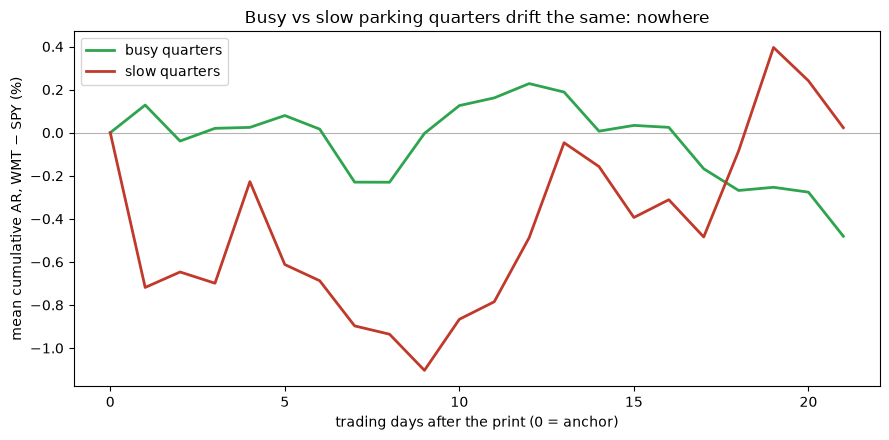

In [3]:
car_b = st.car_path(ev, prices, subset='busy')
car_s = st.car_path(ev, prices, subset='slow')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car_b.index, car_b.values * 100, color='#2ea44f', lw=2, label='busy quarters')
ax.plot(car_s.index, car_s.values * 100, color='#c0392b', lw=2, label='slow quarters')
ax.set_xlabel('trading days after the print (0 = anchor)')
ax.set_ylabel('mean cumulative AR, WMT − SPY (%)')
ax.set_title('Busy vs slow parking quarters drift the same: nowhere')
ax.legend(); plt.tight_layout(); plt.show()

## The numbers

| subset | window | mean AR | *t* |
|---|---|--:|--:|
| busy | 1-week | **+0.08%** | +0.14 |
| busy | 1-month | -0.48% | -0.56 |
| slow | 1-week | -0.61% | -0.64 |
| slow | 1-month | +0.02% | +0.01 |

Every cell is a coin-flip (|*t*| < 0.7). The busy-minus-slow long/short spread is +0.27% (1-week, *t* +0.54) and -0.32% (1-month, *t* -0.39) — and it **flips sign** between the two horizons. The rank correlation between the parking YoY and the forward return is ≈ 0 (-0.04).

In [4]:
for label, col in [('busy 1wk','fwd_s'),('busy 1mo','fwd_l')]:
    s = st.one_sample_t(bz[col].values); print(f'{label:<9s} mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}')
for label, col in [('slow 1wk','fwd_s'),('slow 1mo','fwd_l')]:
    s = st.one_sample_t(sl[col].values); print(f'{label:<9s} mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}')
for label, col in [('L/S 1wk','fwd_s'),('L/S 1mo','fwd_l')]:
    ls = st.longshort_returns(ev, col); s = st.one_sample_t(ls)
    print(f'{label:<9s} mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}')

busy 1wk  mean=+0.080%  t=+0.137
busy 1mo  mean=-0.481%  t=-0.564
slow 1wk  mean=-0.612%  t=-0.643
slow 1mo  mean=+0.023%  t=+0.014
L/S 1wk   mean=+0.271%  t=+0.539
L/S 1mo   mean=-0.316%  t=-0.391


## So what?

The famous *count-the-cars* trade — at least via a stylised, public, ordinal proxy entered at the print — does **not** beat the earnings print. Verdict: **None signal, Mirage tradability.** That squares with the academic finding (Katona et al.) that any *real* satellite edge accrues **early, pre-announcement, to the paying subscribers** and decays as the data diffuses — there's no post-print drift left for a latecomer with a public proxy. The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control that proves the detector isn't just broken.